In [1]:
import os
import pandas as pd
import numpy as np
from fractions import Fraction
from model.lsclib import caseClass, find_caseKey
from scipy import linalg
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection,Line3DCollection
import xarray as xr
#%matplotlib qt5

In [2]:
# File
path_data = "G:\LSCDynRegime_cxy\data"
bn_data = "statistics.feather"
fmt_key = "Lat{Lat:s}_X{X:s}_kH{kH:s}"

In [3]:
# Case
Laₜ_all = (0.35, 0.7, np.inf)
χ_all = (Fraction(1, 2), Fraction(3, 4), Fraction(1, 1), Fraction(4, 3), Fraction(2, 1))
kH_all = (Fraction(5, 2), Fraction(5, 1), Fraction(10, 1)) 
ustar_all = (0.01214, 0.00857, 0.00605) # m/s
H = 25 # m

In [4]:
# Data
key_col = ['cov_uu+','cov_vv+','cov_ww+','tke+','dissip+']
nz = 101
H = 25 # m
zc=np.arange(-nz+1,1,1)/nz*H

In [5]:
# Create case containers 
case_all = dict()
for Laₜ in Laₜ_all:
    for χ in χ_all:
        if Laₜ ==np.inf:
           case = caseClass(Laₜ, χ, 0, ustar_all[0], H)
           case_all[case.key_case] = case
        else:
            for ik, kH in enumerate(kH_all):
                case = caseClass(Laₜ, χ, kH, ustar_all[ik], H)
                case_all[case.key_case] = case

In [7]:
## Read all data
fmt_fn = os.path.join(path_data, "{case:s}", bn_data)
for case in case_all:
    data_col = pd.read_feather(fmt_fn.format(case=case))[key_col]

    case_all[case].data = pd.DataFrame()
    case_all[case].data['cov_uu+'] = data_col['cov_uu+']
    case_all[case].data['cov_vv+'] = data_col['cov_vv+']
    case_all[case].data['cov_ww+'] = data_col['cov_ww+']
    case_all[case].data['tke+'] = data_col['tke+']
    case_all[case].data['dissip+'] = data_col['dissip+']

    #case_all[case].data = case_all[case].data.mean()

In [8]:
ndim = len(case_all)
uu_avg=np.zeros((ndim,101))
vv_avg=np.zeros((ndim,101))
ww_avg=np.zeros((ndim,101))
tke_avg=np.zeros((ndim,101))
dissip_avg=np.zeros((ndim,101))
# Extract data values from data containers
for ic, case in enumerate(case_all):
    uu_avg[ic] = case_all[case].data['cov_uu+']
    vv_avg[ic] = case_all[case].data['cov_vv+']
    ww_avg[ic] = case_all[case].data['cov_ww+']
    tke_avg[ic] = case_all[case].data['tke+']
    dissip_avg[ic] = case_all[case].data['dissip+']

# tke profile

## Normalized by ${u_*}^H$

In [9]:
chi=np.array([0.5,0.5,0.5,
             0.75,0.75,0.75,
             1,1,1,
             4/3,4/3,4/3,
             2,2,2,
             0.5,0.5,0.5,
             0.75,0.75,0.75,
             1,1,1,
             4/3,4/3,4/3,
             2,2,2,
             0.5,0.75,1,4/3,2])

In [10]:
new_scale=(1+1/(chi**3))**(1/3)
tke_avg=tke_avg/(new_scale[:,np.newaxis]**2)
dissip_avg=dissip_avg/(new_scale[:,np.newaxis]**3)

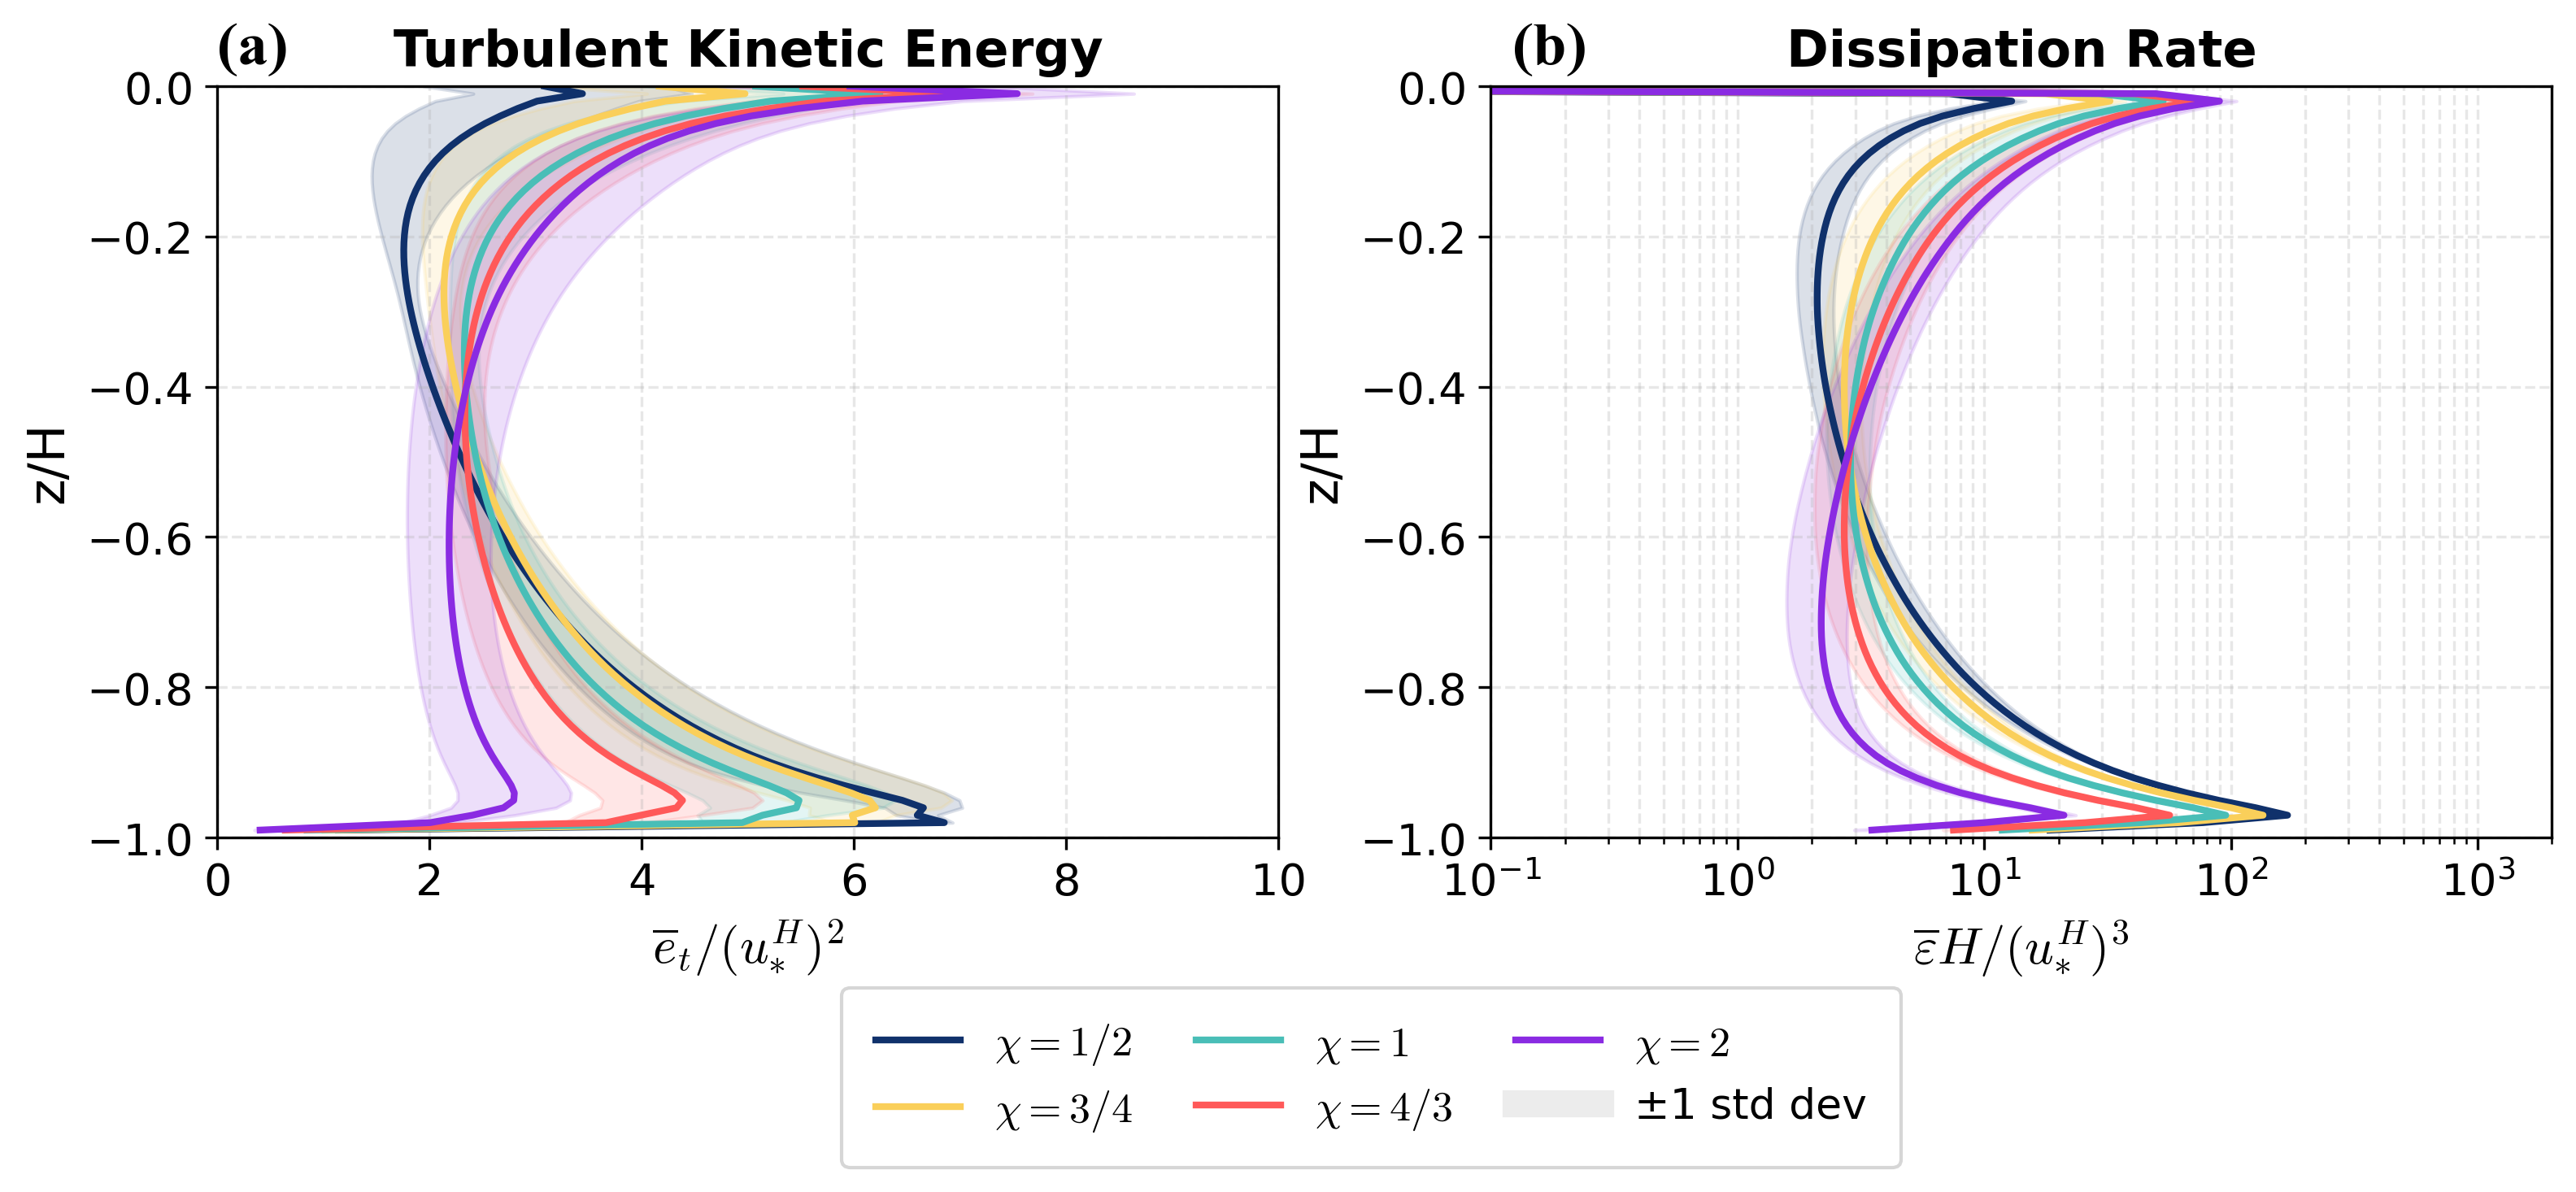

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
plt.rcParams['mathtext.fontset'] = 'cm'
# ============================
# 创建图形
# ============================
fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=300)
fig.subplots_adjust(left=0.08, right=0.95, bottom=0.13, top=0.9, wspace=0.2)

# ============================
# 配置参数
# ============================
# χ值列表和对应标签
chi_values = [0.5, 0.75, 1, 4/3, 2]
chi_labels = ['1/2', '3/4', '1', '4/3', '2']
num_chi = len(chi_values)

# 颜色设置 - 为每个χ值分配不同颜色
colors = ['#10316b', '#facf5a', '#49beb7', '#ff5959', '#8a2be2']

# 配置设置（kH和La_t的组合）
config_labels = [
    '$kH=2.5, La_t=0.35$', '$kH=5, La_t=0.35$', '$kH=10, La_t=0.35$',
    '$kH=2.5, La_t=0.7$', '$kH=5, La_t=0.7$', '$kH=10, La_t=0.7$',
    '$La_t=\infty$'
]

# ============================
# 辅助函数：按配置计算不同χ值的平均廓线
# ============================
def calculate_chi_average_profiles(data_avg, chi_indices_mapping):
    """
    计算每个χ值下所有配置的平均廓线
    
    参数:
    data_avg: 原始数据数组
    chi_indices_mapping: 字典，键为χ值索引，值为该χ值下所有配置的索引列表
    """
    num_chi = len(chi_indices_mapping)
    num_points = len(data_avg[0])
    
    chi_mean_profiles = np.zeros((num_chi, num_points))
    chi_std_profiles = np.zeros((num_chi, num_points))
    
    for chi_idx in range(num_chi):
        if chi_idx in chi_indices_mapping:
            all_config_profiles = []
            
            # 收集该χ值下所有配置的廓线
            for config_idx in chi_indices_mapping[chi_idx]:
                all_config_profiles.append(data_avg[config_idx][::-1])
            
            # 转换为数组并计算所有配置的平均
            all_config_profiles = np.array(all_config_profiles)
            chi_mean_profiles[chi_idx] = np.mean(all_config_profiles, axis=0)
            chi_std_profiles[chi_idx] = np.std(all_config_profiles, axis=0)
    
    return chi_mean_profiles, chi_std_profiles

# ============================
# 根据您的原始代码构建索引映射
# ============================

# TKE数据的χ值索引映射
tke_chi_indices = {}
# 每个χ值对应的配置索引：
# χ=0.5: indices 0-2, 15-17, 30 (共7个配置)
# χ=0.75: indices 3-5, 18-20, 31
# χ=1: indices 6-8, 21-23, 32
# χ=4/3: indices 9-11, 24-26, 33
# χ=2: indices 12-14, 27-29, 34

for chi_idx in range(num_chi):
    indices = []
    # La_t=0.35的3个kH配置
    for i in range(3):
        indices.append(i + chi_idx * 3)
    # La_t=0.7的3个kH配置
    for i in range(3):
        indices.append(i + 15 + chi_idx * 3)
    # La_t=∞配置
    indices.append(30 + chi_idx)
    
    tke_chi_indices[chi_idx] = indices

# Dissipation数据的χ值索引映射（结构与TKE相同）
dissip_chi_indices = {}
for chi_idx in range(num_chi):
    indices = []
    for i in range(3):
        indices.append(i + chi_idx * 3)
    for i in range(3):
        indices.append(i + 15 + chi_idx * 3)
    indices.append(30 + chi_idx)
    
    dissip_chi_indices[chi_idx] = indices

# ============================
# TKE 子图 (左侧) - 按χ值平均
# ============================
ax1 = axes[0]

# 计算每个χ值下所有配置的平均TKE廓线
tke_chi_mean_profiles, tke_chi_std_profiles = calculate_chi_average_profiles(
    tke_avg, tke_chi_indices
)

# 绘制每个χ值的平均廓线
for chi_idx in range(num_chi):
    chi_label = f'$\chi={chi_labels[chi_idx]}$'
    
    ax1.plot(tke_chi_mean_profiles[chi_idx], zc/H, 
             color=colors[chi_idx], linewidth=2.0, linestyle='-',
             label=chi_label)
    
    # 添加误差阴影（±1标准差）
    ax1.fill_betweenx(zc/H, 
                      tke_chi_mean_profiles[chi_idx] - tke_chi_std_profiles[chi_idx],
                      tke_chi_mean_profiles[chi_idx] + tke_chi_std_profiles[chi_idx],
                      color=colors[chi_idx], alpha=0.15)

# 设置TKE子图属性
ax1.set_xlabel(r'$\overline{e}_t/(u_{*}^{H})^2$', fontsize=15)
ax1.set_ylabel(r'z/H', fontsize=15)
ax1.set_title('Turbulent Kinetic Energy', 
              fontsize=15, fontweight='bold')
ax1.set_xlim((0, 10))
ax1.set_ylim((-1, 0))
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.text(0, 1.03, '(a)', transform=ax1.transAxes, fontsize=18, 
         fontweight='bold', fontname='Times New Roman')
ax1.tick_params(axis='both', which='major', labelsize=13)
# ============================
# Dissipation 子图 (右侧) - 按χ值平均
# ============================
ax2 = axes[1]

# 计算每个χ值下所有配置的平均Dissipation廓线
dissip_chi_mean_profiles, dissip_chi_std_profiles = calculate_chi_average_profiles(
    dissip_avg, dissip_chi_indices
)

# 绘制每个χ值的平均廓线（处理对数坐标的负值问题）
PHYSICAL_MIN = 1e-6  # 物理最小值，避免对数坐标中的0或负值

for chi_idx in range(num_chi):
    chi_label = f'$\chi={chi_labels[chi_idx]}$'
    
    # 获取该χ值的平均廓线和标准差
    mean_profile = dissip_chi_mean_profiles[chi_idx]
    std_profile = dissip_chi_std_profiles[chi_idx]
    
    # 确保平均值和边界为正（对数坐标需要）
    mean_pos = np.maximum(mean_profile, PHYSICAL_MIN)
    lower_bound = np.maximum(mean_profile - std_profile, PHYSICAL_MIN)
    upper_bound = np.maximum(mean_profile + std_profile, PHYSICAL_MIN)
    
    # 绘制平均线
    ax2.semilogx(mean_pos, zc/H, 
                 color=colors[chi_idx], linewidth=2.0, linestyle='-',
                 label=chi_label)
    
    # 创建填充区域（使用fill_betweenx但确保正值）
    # 注意：fill_betweenx要求x值递增，这里使用upper_bound和lower_bound
    ax2.fill_betweenx(zc/H, lower_bound, upper_bound,
                      color=colors[chi_idx], alpha=0.15)

# 设置Dissipation子图属性
ax2.set_xlabel(r'$\overline{\varepsilon}H/(u_{*}^{H})^3$', fontsize=15)
ax2.set_ylabel(r'z/H', fontsize=15)
ax2.set_title('Dissipation Rate', 
              fontsize=15, fontweight='bold')
ax2.set_xlim((1e-1, 2000))  # 从较小的正数开始
ax2.set_ylim((-1, 0))
ax2.grid(True, alpha=0.3, linestyle='--', which='both')
ax2.text(0.02, 1.03, '(b)', transform=ax2.transAxes, fontsize=18, 
         fontweight='bold', fontname='Times New Roman')
ax2.tick_params(axis='both', which='major', labelsize=13)

# ============================
# 创建图例
# ============================
# 创建χ值的图例句柄
legend_elements = []
for chi_idx in range(num_chi):
    legend_elements.append(
        Line2D([0], [0], color=colors[chi_idx], lw=2,
               label=f'$\chi={chi_labels[chi_idx]}$')
    )

# 添加误差阴影说明
legend_elements.append(
    Line2D([0], [0], color='gray', lw=8, alpha=0.15,
           label='±1 std dev')
)

# 添加图例
fig.legend(handles=legend_elements, 
           loc='lower center', 
           bbox_to_anchor=(0.51, -0.23),
           ncol=3, 
           fontsize=12.5,
           frameon=True,
           fancybox=True,
           shadow=False,
           borderpad=0.8,
           handlelength=2.0,
           columnspacing=1.5)

# ============================
# 保存和显示
# ============================
plt.savefig('combined_profiles_averaged_by_chi_newscale.png', 
            bbox_inches='tight', dpi=300)

plt.show()

## Normalized by u*s

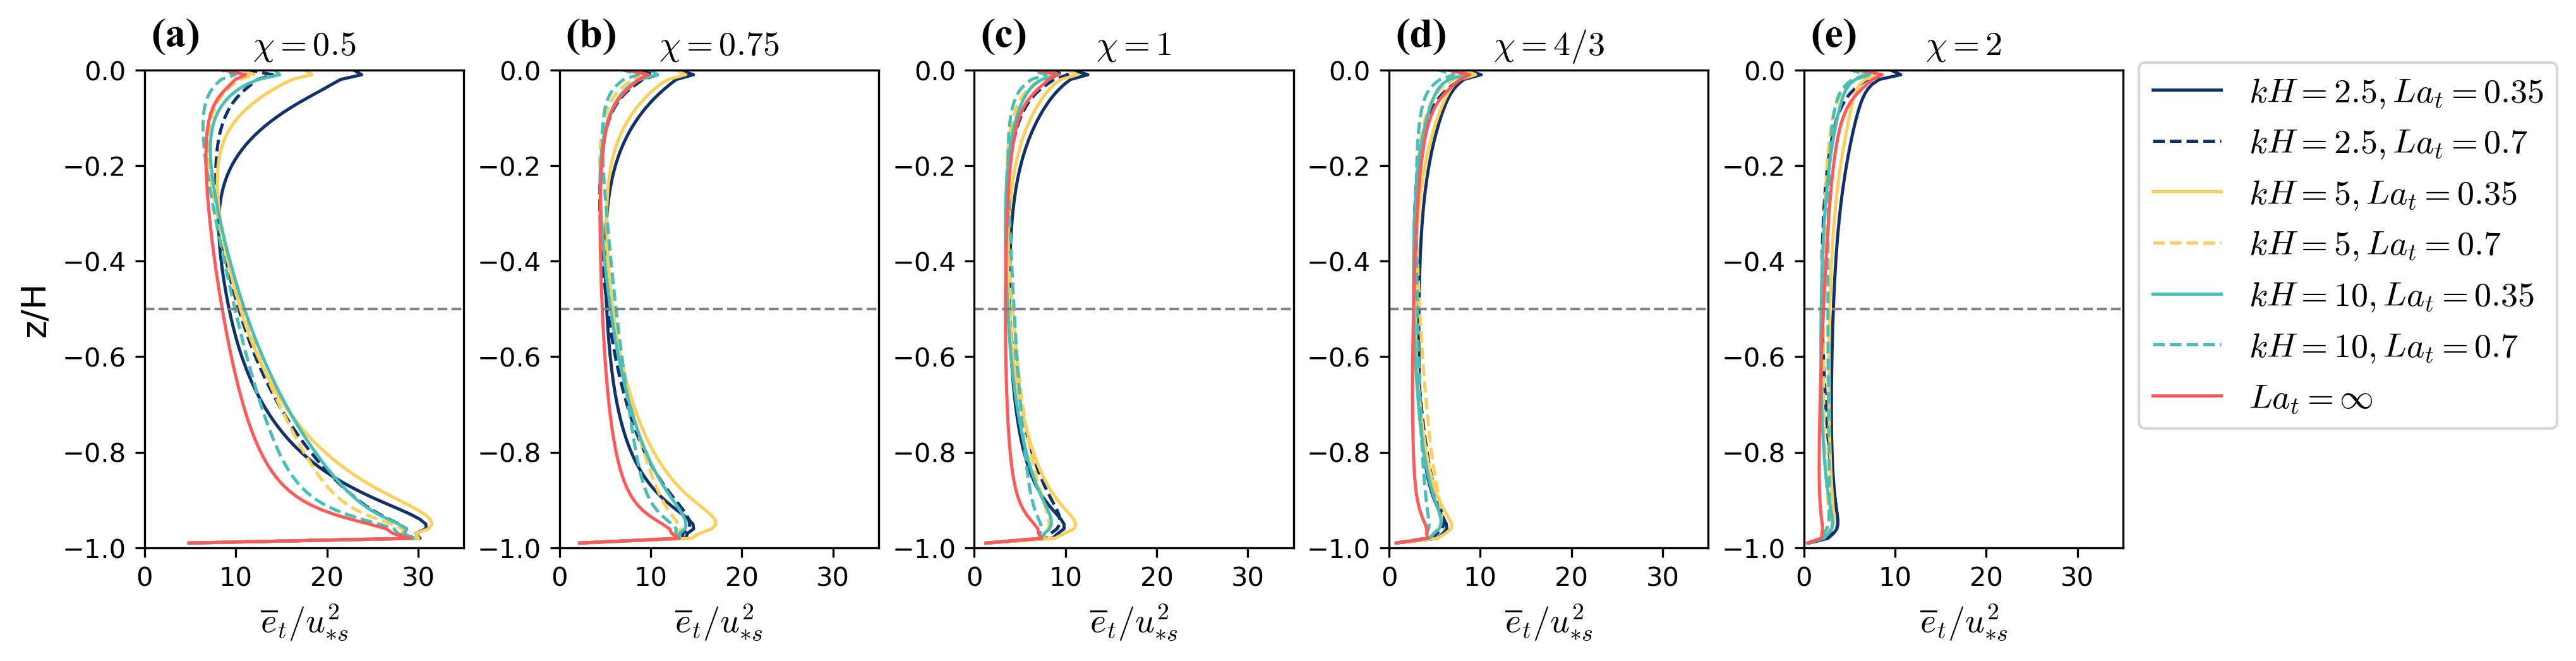

In [9]:
plt.rcParams['mathtext.fontset'] = 'cm'
# tke profile
ifig=1
fig=plt.figure(ifig,figsize=(12,3),dpi=300)
gs=fig.add_gridspec(1,5,left=0.05,right=0.92,bottom=0.12,top=0.96,hspace=0.1,wspace=0.3)
xmin=0
xmax=35

labels=['$kH=2.5,La_t=0.35$','$kH=5,La_t=0.35$','$kH=10,La_t=0.35$','$La_t=\infty$']
labels2=['$kH=2.5,La_t=0.7$','$kH=5,La_t=0.7$','$kH=10,La_t=0.7$','$La_t=\infty}$']
colors=['#10316b','#facf5a','#49beb7','cyan','#ff5959']
lines=['-','--']
subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)']

ax1=fig.add_subplot(gs[0])
for i in range(0,3):
    ax_u1_profile=ax1.plot(tke_avg[i][::-1],zc/H,color=colors[i],linewidth=1.2,linestyle=lines[0],label=labels[i])
    ax_u2_profile=ax1.plot(tke_avg[i+15][::-1],zc/H,color=colors[i],linewidth=1.2,linestyle=lines[1],label=labels2[i])

ax2=fig.add_subplot(gs[1])
for i in range(0,3):
    ax_u3_profile=ax2.plot(tke_avg[i+3][::-1],zc/H,color=colors[i],linewidth=1.2,linestyle=lines[0],label=labels[i])
    ax_u4_profile=ax2.plot(tke_avg[i+18][::-1],zc/H,color=colors[i],linewidth=1.2,linestyle=lines[1],label=labels2[i])

ax3=fig.add_subplot(gs[2])
for i in range(0,3):
    ax_u5_profile=ax3.plot(tke_avg[i+6][::-1],zc/H,color=colors[i],linewidth=1.2,linestyle=lines[0],label=labels[i])
    ax_u6_profile=ax3.plot(tke_avg[i+21][::-1],zc/H,color=colors[i],linewidth=1.2,linestyle=lines[1],label=labels2[i])

ax4=fig.add_subplot(gs[3])
for i in range(0,3):
    ax_u7_profile=ax4.plot(tke_avg[i+9][::-1],zc/H,color=colors[i],linewidth=1.2,linestyle=lines[0],label=labels[i])
    ax_u8_profile=ax4.plot(tke_avg[i+24][::-1],zc/H,color=colors[i],linewidth=1.2,linestyle=lines[1],label=labels2[i])

ax5=fig.add_subplot(gs[4])
for i in range(0,3):
    ax_u9_profile=ax5.plot(tke_avg[i+12][::-1],zc/H,color=colors[i],linewidth=1.2,linestyle=lines[0],label=labels[i])
    ax_u10_profile=ax5.plot(tke_avg[i+27][::-1],zc/H,color=colors[i],linewidth=1.2,linestyle=lines[1],label=labels2[i])

ax1.plot(tke_avg[30][::-1],zc/H,color=colors[4],linewidth=1.2,linestyle=lines[0],label=labels[3])
ax2.plot(tke_avg[31][::-1],zc/H,color=colors[4],linewidth=1.2,linestyle=lines[0],label=labels[3])
ax3.plot(tke_avg[32][::-1],zc/H,color=colors[4],linewidth=1.2,linestyle=lines[0],label=labels[3])
ax4.plot(tke_avg[33][::-1],zc/H,color=colors[4],linewidth=1.2,linestyle=lines[0],label=labels[3])
ax5.plot(tke_avg[34][::-1],zc/H,color=colors[4],linewidth=1.2,linestyle=lines[0],label=labels[3])

for ax in [ax1, ax2, ax3, ax4, ax5]:
    ax.axhline(y=-0.5, color='gray', linestyle='--', linewidth=1.0)
# 添加子图序号
ax1.text(0.02, 1.05, subplot_labels[0], transform=ax1.transAxes, fontsize=16, fontweight='bold',fontname='Times new roman')
ax2.text(0.02, 1.05, subplot_labels[1], transform=ax2.transAxes, fontsize=16, fontweight='bold',fontname='Times new roman')
ax3.text(0.02, 1.05, subplot_labels[2], transform=ax3.transAxes, fontsize=16, fontweight='bold',fontname='Times new roman')
ax4.text(0.02, 1.05, subplot_labels[3], transform=ax4.transAxes, fontsize=16, fontweight='bold',fontname='Times new roman')
ax5.text(0.02, 1.05, subplot_labels[4], transform=ax5.transAxes, fontsize=16, fontweight='bold',fontname='Times new roman')

ax1.set_xlabel(r'$\overline{e}_t/{u_{*s}^2}$',fontsize=13)
ax1.set_ylabel('z/H',fontsize=13)
ax1.set_title('$\chi=0.5$',fontsize=13)
ax1.set_xlim((0,xmax))
ax1.set_ylim((-1,0))
ax5.legend(bbox_to_anchor=(1.05, 0.25), loc=3, borderaxespad=0,fontsize=13)#bbox_to_anchor=(0.7, 1),loc=3)#bbox_to_anchor=(0.2, 1)

ax2.set_xlabel(r'$\overline{e}_t/{u_{*s}^2}$',fontsize=13)
ax2.set_title('$\chi=0.75$',fontsize=13)
#ax2.set_ylabel('Z(m)')
ax2.set_xlim((0,xmax))
ax2.set_ylim((-1,0))
#ax2.legend(loc="lower right")

ax3.set_xlabel(r'$\overline{e}_t/{u_{*s}^2}$',fontsize=13)
ax3.set_title('$\chi=1$',fontsize=13)
#ax3.set_ylabel('Z(m)')
ax3.set_xlim((0,xmax))
ax3.set_ylim((-1,0))
#ax2.legend(loc="lower right")

ax4.set_xlabel(r'$\overline{e}_t/{u_{*s}^2}$',fontsize=13)
#ax4.set_ylabel('Z(m)')
ax4.set_title('$\chi=4/3$',fontsize=13)
ax4.set_xlim((0,xmax))
ax4.set_ylim((-1,0))
#ax2.legend(loc="lower right")

ax5.set_xlabel(r'$\overline{e}_t/{u_{*s}^2}$',fontsize=13)
#ax5.set_ylabel('Z(m)')
ax5.set_title('$\chi=2$',fontsize=13)
ax5.set_xlim((0,xmax))
ax5.set_ylim((-1,0))
#ax2.legend(loc="lower right")

fig.savefig('tke_profile',bbox_inches='tight',dpi=300)
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_6928\4143719330.py:62: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set_xlim((0,xmax))
C:\Users\Administrator\AppData\Local\Temp\ipykernel_6928\4143719330.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax2.set_xlim((0,xmax))
C:\Users\Administrator\AppData\Local\Temp\ipykernel_6928\4143719330.py:76: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax3.set_xlim((0,xmax))
C:\Users\Administrator\AppData\Local\Temp\ipykernel_6928\4143719330.py:83: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax4.set_xlim((0,xmax))
C:\Users\Administrator\AppData\Local\Temp\ipykernel_6928\4143719330.py:90: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax5.set_xlim((0,xmax))


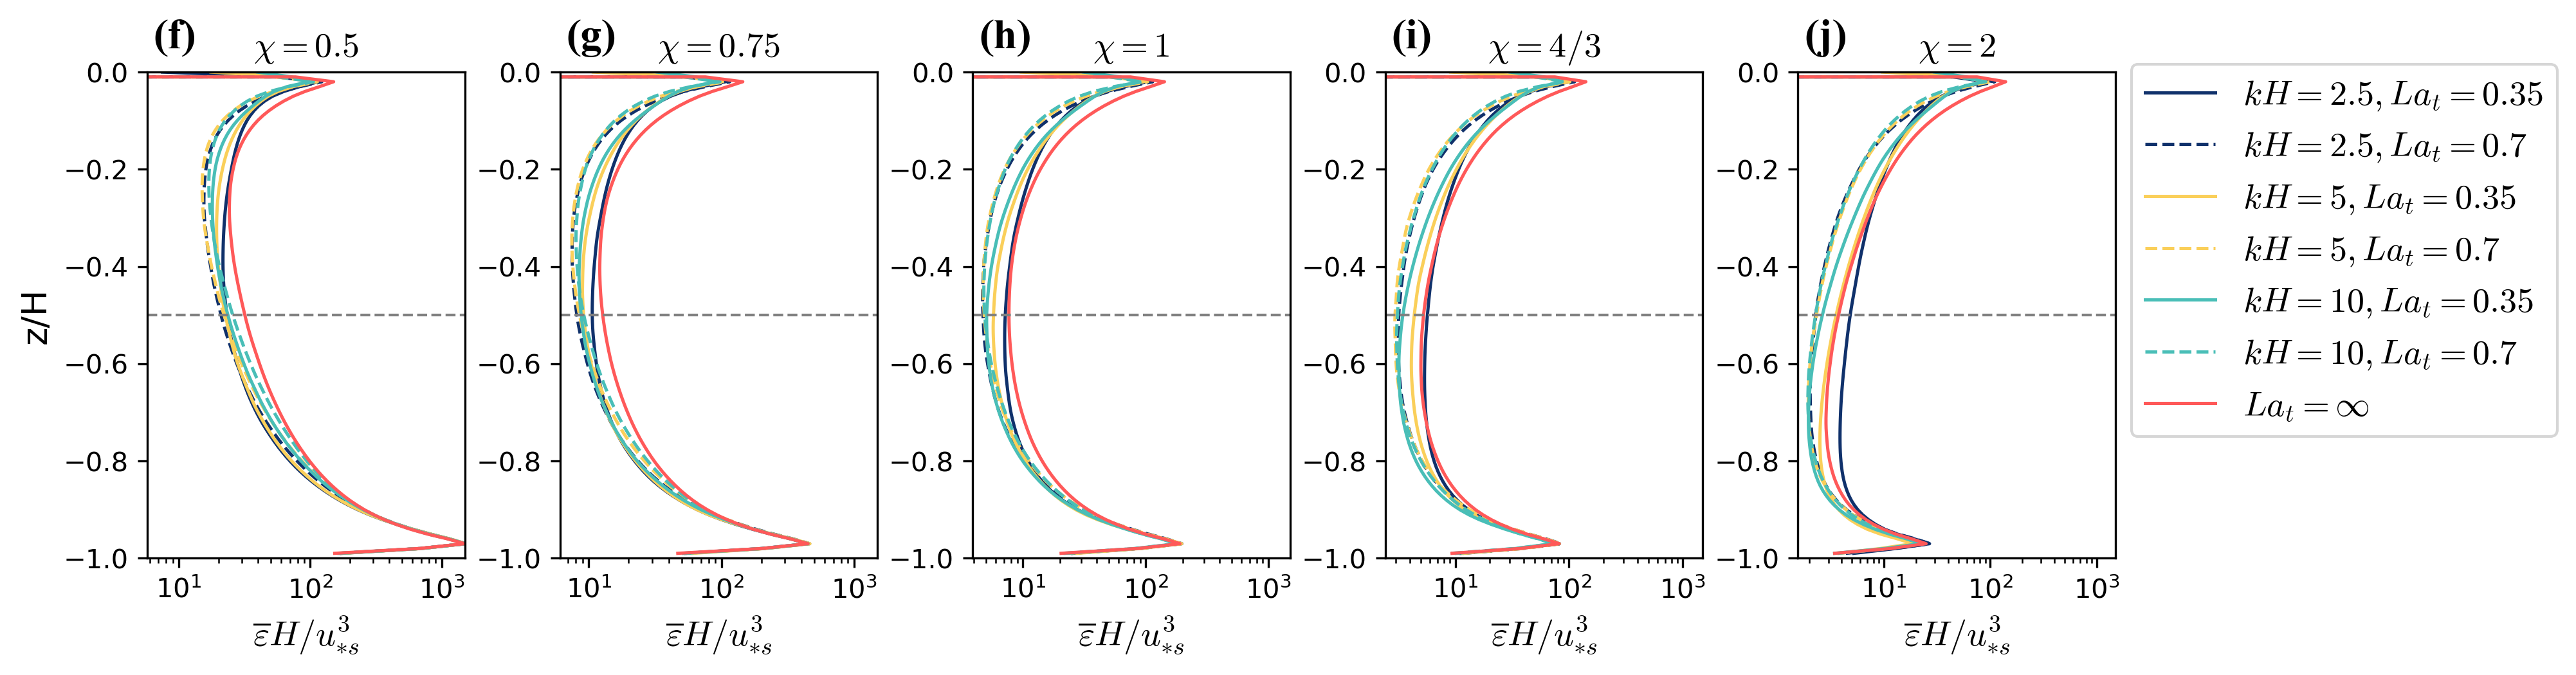

In [13]:
plt.rcParams['mathtext.fontset'] = 'cm'
# dissip profile
ifig=1
fig=plt.figure(ifig,figsize=(12,3),dpi=300)
gs=fig.add_gridspec(1,5,left=0.05,right=0.90,bottom=0.12,top=0.96,hspace=0.1,wspace=0.3)
#plt.suptitle("Lat0.7",fontsize=12,x=0.47, y=1)
xmin=0
xmax=1500

labels=['$kH=2.5,La_t=0.35$','$kH=5,La_t=0.35$','$kH=10,La_t=0.35$','$La_t=\infty$']
labels2=['$kH=2.5,La_t=0.7$','$kH=5,La_t=0.7$','$kH=10,La_t=0.7$','$La_t=\infty}$']
colors=['#10316b','#facf5a','#49beb7','cyan','#ff5959']
lines=['-','--']
# 子图序号标签
subplot_labels = ['(f)', '(g)', '(h)', '(i)', '(j)']

ax1=fig.add_subplot(gs[0])
for i in range(0,3):
    ax_u1_profile=ax1.semilogx(dissip_avg[i][::-1],zc/H,color=colors[i],linewidth=1.2,linestyle=lines[0],label=labels[i])
    ax_u2_profile=ax1.semilogx(dissip_avg[i+15][::-1],zc/H,color=colors[i],linewidth=1.2,linestyle=lines[1],label=labels2[i])


ax2=fig.add_subplot(gs[1])
for i in range(0,3):
    ax_u3_profile=ax2.semilogx(dissip_avg[i+3][::-1],zc/H,color=colors[i],linewidth=1.2,linestyle=lines[0],label=labels[i])
    ax_u4_profile=ax2.semilogx(dissip_avg[i+18][::-1],zc/H,color=colors[i],linewidth=1.2,linestyle=lines[1],label=labels2[i])

ax3=fig.add_subplot(gs[2])
for i in range(0,3):
    ax_u5_profile=ax3.semilogx(dissip_avg[i+6][::-1],zc/H,color=colors[i],linewidth=1.2,linestyle=lines[0],label=labels[i])
    ax_u6_profile=ax3.semilogx(dissip_avg[i+21][::-1],zc/H,color=colors[i],linewidth=1.2,linestyle=lines[1],label=labels2[i])

ax4=fig.add_subplot(gs[3])
for i in range(0,3):
    ax_u7_profile=ax4.semilogx(dissip_avg[i+9][::-1],zc/H,color=colors[i],linewidth=1.2,linestyle=lines[0],label=labels[i])
    ax_u8_profile=ax4.semilogx(dissip_avg[i+24][::-1],zc/H,color=colors[i],linewidth=1.2,linestyle=lines[1],label=labels2[i])

ax5=fig.add_subplot(gs[4])
for i in range(0,3):
    ax_u9_profile=ax5.semilogx(dissip_avg[i+12][::-1],zc/H,color=colors[i],linewidth=1.2,linestyle=lines[0],label=labels[i])
    ax_u10_profile=ax5.semilogx(dissip_avg[i+27][::-1],zc/H,color=colors[i],linewidth=1.2,linestyle=lines[1],label=labels2[i])

ax1.plot(dissip_avg[30][::-1],zc/H,color=colors[4],linewidth=1.2,linestyle=lines[0],label=labels[3])
ax2.plot(dissip_avg[31][::-1],zc/H,color=colors[4],linewidth=1.2,linestyle=lines[0],label=labels[3])
ax3.plot(dissip_avg[32][::-1],zc/H,color=colors[4],linewidth=1.2,linestyle=lines[0],label=labels[3])
ax4.plot(dissip_avg[33][::-1],zc/H,color=colors[4],linewidth=1.2,linestyle=lines[0],label=labels[3])
ax5.plot(dissip_avg[34][::-1],zc/H,color=colors[4],linewidth=1.2,linestyle=lines[0],label=labels[3])

for ax in [ax1, ax2, ax3, ax4, ax5]:
    ax.axhline(y=-0.5, color='gray', linestyle='--', linewidth=1.0)

# 添加子图序号
ax1.text(0.02, 1.05, subplot_labels[0], transform=ax1.transAxes, fontsize=16, fontweight='bold',fontname='Times new roman')
ax2.text(0.02, 1.05, subplot_labels[1], transform=ax2.transAxes, fontsize=16, fontweight='bold',fontname='Times new roman')
ax3.text(0.02, 1.05, subplot_labels[2], transform=ax3.transAxes, fontsize=16, fontweight='bold',fontname='Times new roman')
ax4.text(0.02, 1.05, subplot_labels[3], transform=ax4.transAxes, fontsize=16, fontweight='bold',fontname='Times new roman')
ax5.text(0.02, 1.05, subplot_labels[4], transform=ax5.transAxes, fontsize=16, fontweight='bold',fontname='Times new roman')

ax1.set_xlabel(r'$\overline{\varepsilon}H/{u_{*s}^3}$',fontsize=13)
ax1.set_ylabel('z/H',fontsize=13)
ax1.set_title('$\chi=0.5$',fontsize=13)
ax1.set_xlim((0,xmax))
ax1.set_ylim((-1,0))
ax5.legend(bbox_to_anchor=(1.05, 0.25), loc=3, borderaxespad=0,fontsize=13)#bbox_to_anchor=(0.7, 1),loc=3)#bbox_to_anchor=(0.2, 1)

ax2.set_xlabel(r'$\overline{\varepsilon}H/{u_{*s}^3}$',fontsize=13)
ax2.set_title('$\chi=0.75$',fontsize=13)
# ax2.set_ylabel('z/H')
ax2.set_xlim((0,xmax))
ax2.set_ylim((-1,0))
#ax2.legend(loc="lower right")

ax3.set_xlabel(r'$\overline{\varepsilon}H/{u_{*s}^3}$',fontsize=13)
ax3.set_title('$\chi=1$',fontsize=13)
# ax3.set_ylabel('z/H')
ax3.set_xlim((0,xmax))
ax3.set_ylim((-1,0))
#ax2.legend(loc="lower right")

ax4.set_xlabel(r'$\overline{\varepsilon}H/{u_{*s}^3}$',fontsize=13)
# ax4.set_ylabel('z/H')
ax4.set_title('$\chi=4/3$',fontsize=13)
ax4.set_xlim((0,xmax))
ax4.set_ylim((-1,0))
#ax2.legend(loc="lower right")

ax5.set_xlabel(r'$\overline{\varepsilon}H/{u_{*s}^3}$',fontsize=13)
# ax5.set_ylabel('z/H')
ax5.set_title('$\chi=2$',fontsize=13)
ax5.set_xlim((0,xmax))
ax5.set_ylim((-1,0))


fig.savefig('dissip_profile',bbox_inches='tight')
plt.show()